In [1]:
# Importing required packages
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from numpy.polynomial import Polynomial
from matplotlib.gridspec import GridSpec

In [2]:
# Appending the current working directory to the system path of python
curr_path=os.getcwd()
sys.path.append(curr_path)

In [3]:
%run my_table.ipynb

#################################################################################################
## Input parameters - BDH problem

In [4]:
# All input variables related to BDH example

# Input parameters: 
# 1. Oil field input parameters
# period            Number of periods of production, years
# reserve           Initial reserve, MMBD
# decline           Yearly decline rate, fraction
# prod_level        Initial yearly production level, MMBD
# op_cost           Variable operational cost per barrel of oil at Year 0, $
# op_cost_rate      Yearly growth rate for variable operational cost, fraction 
# price             Initial oil price per barrel, $
# price_growth      Yearly growth rate of oil price, fraction
# fixed_cost        Yearly fixed cost, MM$
# profit            Profit sharing rate, fraction
# dr                Risk-adjusted discount rate
# init_invest       Up=front investment, MM$

# BDH problema
period = 10
reserve = 90
prod_level = 9
decline = 0.15
op_cost = 10
op_cost_rate = 0.02
price = 25
price_growth = 0.0 # BDH = 0.03; Ahmandi&Bratvold = 0.00 
fixed_cost = 5
profit = 0.25
dr = 0.05  # BDH = 0.1 Ahmandi&Bratvold = 0.05 (used risk-neutral valuation approach)
rf = 0.05 # risk-free rate
init_invest = 180

frame, market_val, NPV = table_(period, reserve, prod_level, decline, op_cost, op_cost_rate, price, price_growth, fixed_cost, profit, dr, init_invest)

# My suggestion for production curve
#frame, market_val, NPV = table_w(period, reserve, prod_level, decline, op_cost, op_cost_rate, price, price_growth, fixed_cost, profit, dr, init_invest)

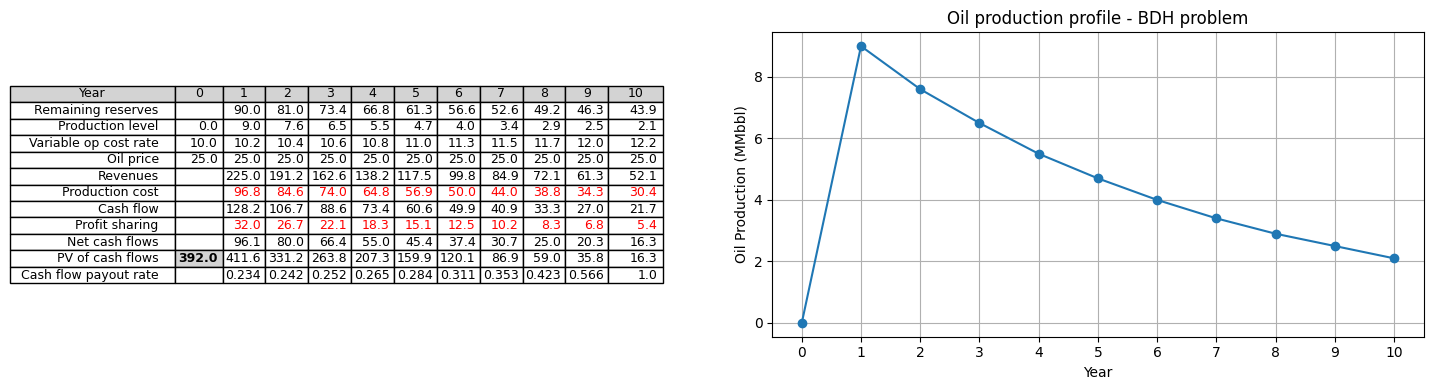

Value of the initial investment: $180.0
PV of cash flows: $392.0
Net Present Value: $212.0


In [5]:
# Plo table

%run plot_table.ipynb

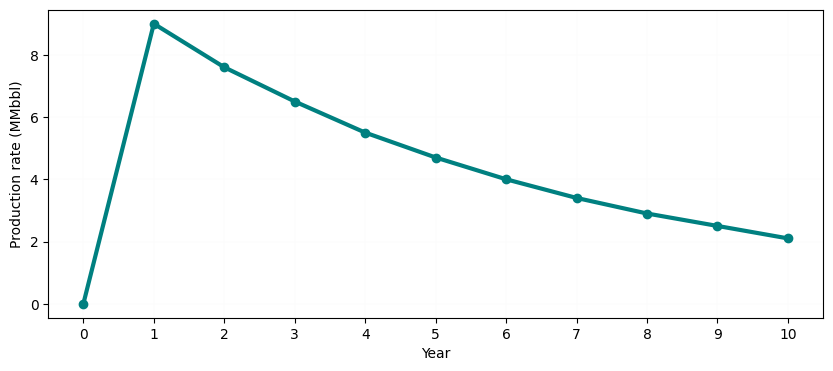

In [6]:
# Plot production profile

%run plot_prod_profile.ipynb

#################################################################################################
## Geometrical Brownian Motion

In [7]:
# 2. Price model input parameters

# 2.1. Oil price model (OP)
# 2.1.1. Geometrical Brownian Motion (GBM) Model
p0_OP = price                # start price at time 0
mu_GBM_OP = price_growth     # annulazied drift parameter of GBM process
sigma_GBM_OP = 0.15           # annulazied volatility parameter of GBM process

# 2.2. Variable operating cost model (VOC)
# 2.2.1. Geometrical Brownian Motion (GBM) Model
p0_VOC = op_cost
mu_GBM_VOC = op_cost_rate
sigma_GBM_VOC = 0.10


In [8]:
# 3. Model configuration

# trialno       number of simulation trials or paths
# T             total time in years (also called deltaT)
# rf            risk-free rate
# dr            Risk-adjusted discount rate
# DR            discount rate coefficient (=1/(1+r))

trialno = 10000
T = 10

dt = 1/5                      # granularity of time-period 
time = np.arange(dt, T+dt, dt)  # time points
N = len(time)                   # number of time intervals

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


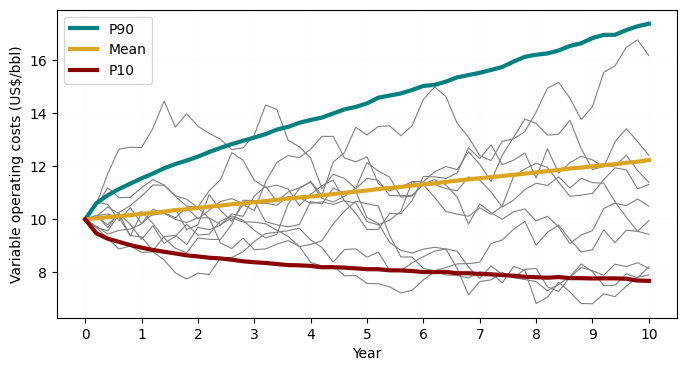

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


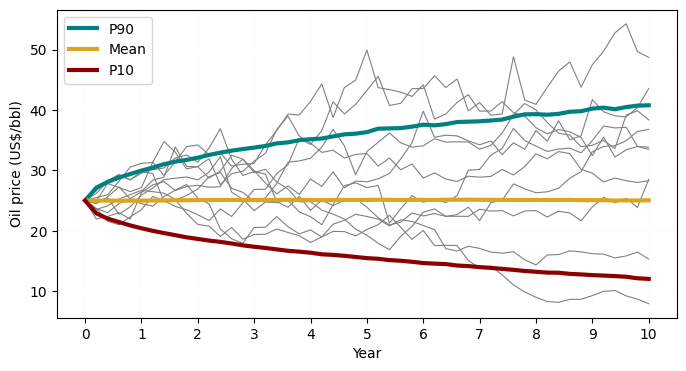

In [9]:
%run GBM_function.ipynb

In [10]:
dt = 1                       
time = np.arange(dt, T+dt, dt)  
N = len(time)                  
%run GBM_function2.ipynb

#################################################################################################
## Cash Flow

In [11]:
# CASH FLOW
%run cash_flow.ipynb

CASH FLOW
             0           1           2           3          4          5   \
Path 1      0.0   56.890116   11.612316    -13.4339  -8.571431 -16.343244   
Path 2      0.0    87.02754   80.352924   75.476667  42.264886  37.368264   
Path 3      0.0   52.709632   48.625991   38.510164  36.235506  51.548219   
0           ...         ...         ...         ...        ...        ...   
Path 9998   0.0   68.077007   46.749444   24.920795  27.932007  33.893946   
Path 9999   0.0  110.286425   82.103257   46.706433  51.384959  42.257016   
Path 10000  0.0  149.589098  137.243939  136.518796  101.03913  74.251313   

                   6          7          8          9          10  
Path 1     -12.564538 -18.341322 -22.471379 -17.113858 -19.810098  
Path 2       24.42483  32.812223  13.381482  18.351719  19.142793  
Path 3      41.719572  29.972416  29.901885  35.519928   35.88471  
0                 ...        ...        ...        ...        ...  
Path 9998   25.500679   8.990196 

#################################################################################################
## Value of the project without options

In [12]:
%run present_value.ipynb

Value of the initial investment: $180.0
PV of cash flows: $392.9
Value of the project without options (NPV): $212.9


#################################################################################################
## Value of the project with options

In [22]:
# LSM approach (regression used)
degree = 2
poly_type = 'laguerre'  # poly_type (str): Type of polynomial ('poly', 'hermite', 'legendre', 'chebyshev', 'jacobi', 'laguerre').

# years to exercise options on a list
option_times = [1,2,3,4,5,6,7,8,9,10]
#option_times = [5]
# The list of options must be written in the form of a dictionary with option label as the key, and option expense and cash flow reward as the value.
options = {'continue': [0, 0], 'buyout': [40, 25], 'divest': [0, 100]}

%run apply_options.ipynb

Options times:   0%|          | 0/10 [00:00<?, ?time/s]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


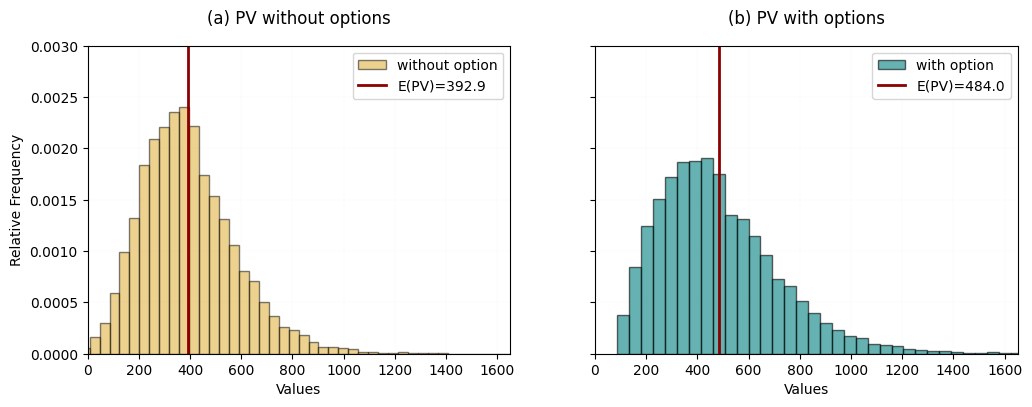

In [25]:
import numpy as np  # Certifique-se de importar numpy
import matplotlib.pyplot as plt

def plot_density_and_frequency(s1, s2, bins=50):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    # Sem opção
    axes[0].set_axisbelow(True)
    axes[0].hist(s1, bins=bins, density=True, color='goldenrod', alpha=0.5, edgecolor='black', label="without option")
    axes[0].axvline(x=np.mean(s1), color='darkred', linestyle='-', lw=2, label=f'E(PV)={np.mean(s1):.1f}')
    axes[0].set_xlabel("Values")
    axes[0].set_ylabel("Relative Frequency")
    axes[0].set_xlim([0, 1650])
    axes[0].set_ylim(0, 0.0030)
    axes[0].legend()
    axes[0].grid(lw=0.1, color="0.94")
    # Subtítulo
    #axes[0].text(0.5, -0.25, "(a) PV without options", ha='center', va='center', transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title("(a) PV without options", loc='center', fontsize=12, pad=16)

    # Com opção
    axes[1].set_axisbelow(True)
    axes[1].hist(s2, bins=bins, density=True, color='teal', alpha=0.6, edgecolor='black', label="with option")
    axes[1].axvline(x=np.mean(s2), color='darkred', linestyle='-', lw=2, label=f'E(PV)={np.mean(s2):.1f}')
    axes[1].set_xlabel("Values")
    axes[1].set_xlim([0, 1650])
    axes[1].set_ylim(0, 0.0030)
    axes[1].legend()
    axes[1].grid(lw=0.1, color="0.94")
    # Subtítulo
    #axes[1].text(0.5, -0.25, "(b) PV with options", ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title("(b) PV with options", loc='center', fontsize=12, pad=16)


    # Salvar figura
    output_path = r"C:\Users\calva\OneDrive\Documentos\Doutorado\paper_com_Bratvold\sn-article-template\density_NPV_2.eps"
    plt.savefig(output_path, format='eps', dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()


# Exemplo de uso
s1 = present_value(df1, dr)
s2 = present_value(df_cf_options, dr)
plot_density_and_frequency(s1, s2)

# analise extra

In [26]:
# LSM approach (regression used)
degree = 2
poly_type = 'laguerre'  # poly_type (str): Type of polynomial ('poly', 'hermite', 'legendre', 'chebyshev', 'jacobi', 'laguerre').

# The list of options must be written in the form of a dictionary with option label as the key, and option expense and cash flow reward as the value.
options = {'continue': [0, 0], 'buyout': [40, 25], 'divest': [0, 100]}

# Listas para armazenar os resultados
pv_single = []  # Cada option_times é [i]
pv_cumulative = []  # option_times é [1], [1,2], ..., [1,2,...,10]

# IMPORTANTE: Adapte para capturar a saída correta do seu notebook
for i in range(1, 11):
    # 1. Variação single
    option_times = [i]
    %run apply_options.ipynb  # Executa o notebook com option_times definido
    pv_single.append(pv)  # Substitua pelo nome da variável de saída
    
    # 2. Variação cumulativa
    option_times = list(range(1, i+1))
    %run apply_options.ipynb
    pv_cumulative.append(pv)

pv_single_fmt = [round(float(x), 1) for x in pv_single]
pv_cumulative_fmt = [round(float(x), 1) for x in pv_cumulative]

print("PV (single option_times):", pv_single_fmt)
print("PV (cumulative option_times):", pv_cumulative_fmt)

Options times:   0%|          | 0/1 [00:00<?, ?time/s]

Options times:   0%|          | 0/1 [00:00<?, ?time/s]

Options times:   0%|          | 0/1 [00:00<?, ?time/s]

Options times:   0%|          | 0/2 [00:00<?, ?time/s]

Options times:   0%|          | 0/1 [00:00<?, ?time/s]

...

Options times:   0%|          | 0/1 [00:00<?, ?time/s]

Options times:   0%|          | 0/9 [00:00<?, ?time/s]

Options times:   0%|          | 0/1 [00:00<?, ?time/s]

Options times:   0%|          | 0/10 [00:00<?, ?time/s]

PV (single option_times): [455.4, 436.7, 426.4, 421.9, 421.9, 425.0, 430.8, 438.6, 447.3, 454.3]
PV (cumulative option_times): [455.4, 456.6, 459.9, 463.9, 468.0, 471.9, 475.9, 479.8, 483.1, 484.0]


# analise extra

#####################################################################################################################

In [28]:
import pandas as pd

def count_option_occurrences(df_options):
    """
    Counts occurrences of 'buyout', 'continue', and 'divest' in each column of a DataFrame.

    Parameters:
    df_options (pd.DataFrame): DataFrame containing categorical values ('buyout', 'continue', 'divest').

    Returns:
    pd.DataFrame: DataFrame with counts of each option per column.
    """
    # Define the options to count
    options = ['buyout', 'continue', 'divest']
    
    # Count occurrences of each option in every column
    option_counts = {option: df_options.apply(lambda col: (col == option).sum()) for option in options}
    
    # Convert dictionary to DataFrame
    result_df = pd.DataFrame(option_counts)
    
    return result_df

count_option_occurrences(df_options).T

,0,1,2,3,4,5,6,7,8,9,10
buyout,0,9930,2,1,1,0,0,0,0,0,0
continue,0,33,9660,8942,7901,6546,4964,3206,1366,140,0
divest,0,37,301,719,1041,1356,1582,1758,1840,1226,140


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


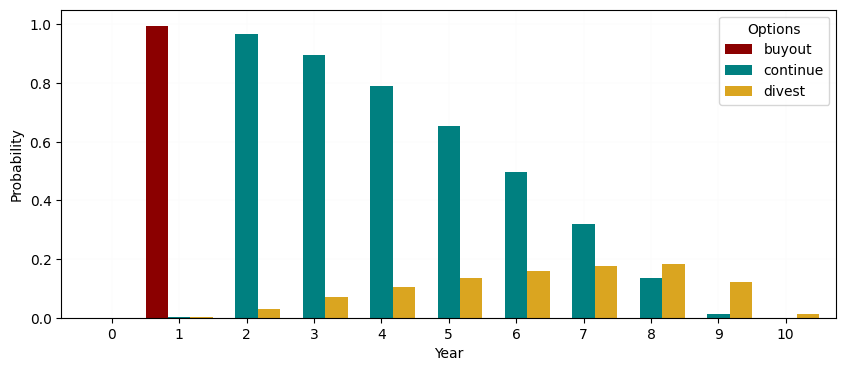

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados de exemplo

# Criando o DataFrame
df = pd.DataFrame(count_option_occurrences(df_options).T, index=["buyout", "continue", "divest"]).T
df_prob = df/trialno
# Plotando o gráfico de barras
cores = ['darkred', 'teal', 'goldenrod']
ax = df_prob.plot(kind='bar', figsize=(10, 4), width=1., color=cores)

# Configurações adicionais
plt.xlabel('Year')
plt.ylabel('Probability')
plt.xticks(rotation=0)  # Mantém os rótulos do eixo x na horizontal
plt.legend(title='Options')  # Legenda fora do gráfico
ax.set_axisbelow(True)
plt.grid(lw=0.1, color="0.94")
plt.ylim(0, 1.05)

# Salvar figura
output_path = r"C:\Users\calva\OneDrive\Documentos\Doutorado\paper_com_Bratvold\sn-article-template\options_prob.eps"
plt.savefig(output_path, format='eps', dpi=300, bbox_inches='tight')

plt.show()
plt.close()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


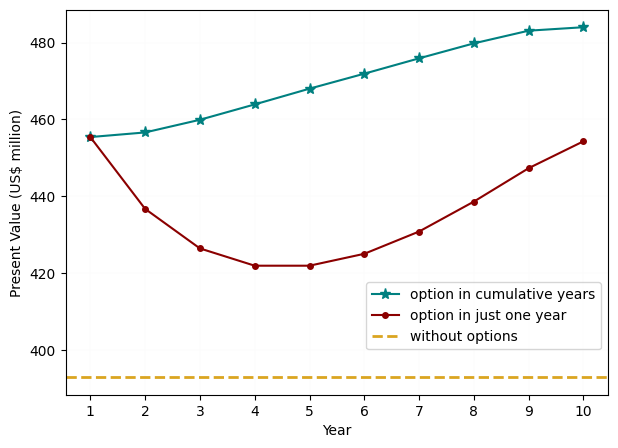

In [30]:
plt.figure(figsize=(7, 5))

plt.plot(time, pv_cumulative_fmt, marker='*', ms=8, label='option in cumulative years', color='teal')
plt.plot(time, pv_single_fmt, marker='.', ms=8, label='option in just one year', color='darkred')
plt.axhline(pv_without, color='goldenrod', linestyle='--', linewidth=2, label='without options')
#plt.text(x=3.5, y=pv_without + 1., s='PV without options', color='goldenrod', fontsize=10, ha='center')
plt.xlabel('Year')
plt.ylabel('Present Value (US$ million)')

plt.grid(lw=0.1, color="0.94")
plt.legend(loc='lower right', bbox_to_anchor=(1, 0.1))

# Garante que o eixo x vai mostrar exatamente os valores do array time
plt.xticks(ticks=time, labels=[str(i) for i in time])

# Salvar figura
output_path = r"C:\Users\calva\OneDrive\Documentos\Doutorado\paper_com_Bratvold\sn-article-template\graph_options.eps"
plt.savefig(output_path, format='eps', dpi=300, bbox_inches='tight')

plt.show()
plt.close()


In [31]:
import pandas as pd
import numpy as np

# Supondo que seu array seja chamado oil_price
# oil_price = np.array([...])  # seu array

# Número de linhas e colunas
n_linhas, n_colunas = oil_price.shape

# Criando nomes para as linhas e colunas
index = [f'Path {i+1}' for i in range(n_linhas)]
columns = list(range(n_colunas))  # ou use [f't={i}' for i in range(n_colunas)] se preferir

# Criando o DataFrame
oil_price_df = pd.DataFrame(oil_price, index=index, columns=columns)
VOC_price_df = pd.DataFrame(VOC_price, index=index, columns=columns)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


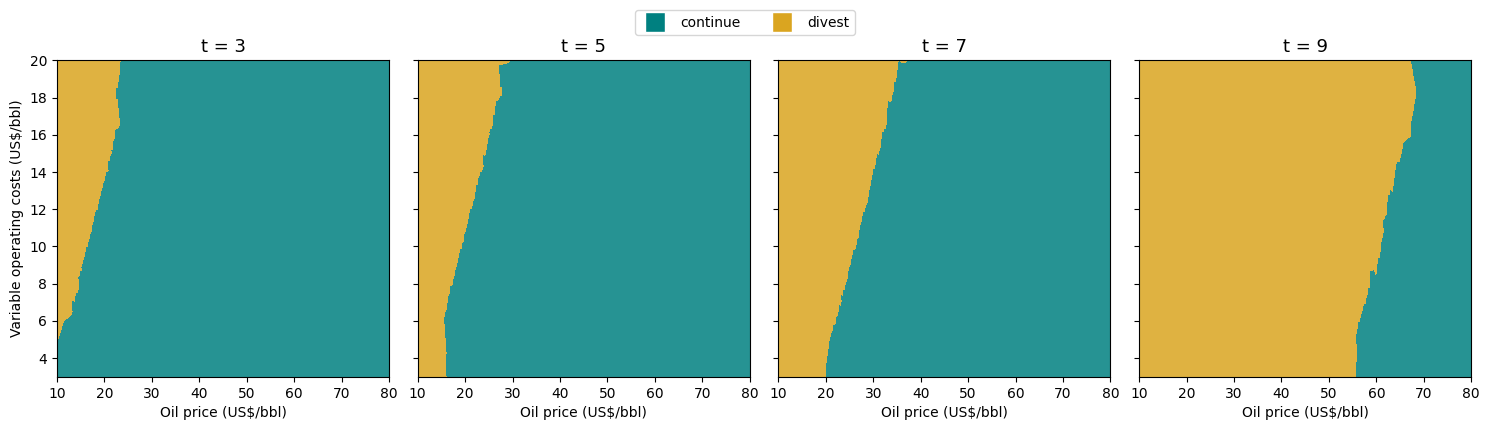

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier

col_list = [3, 5, 7, 9]
option_map = {'continue': 0, 'divest': 1}
colors = ['teal', 'goldenrod']
labels = ['continue', 'divest']
cmap = ListedColormap(colors)

# Limites desejados
voc_min, voc_max = 3, 20
oil_min, oil_max = 10, 80

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

for i, (ax, col_t) in enumerate(zip(axes, col_list)):
    oil_price_t = oil_price_df.iloc[:, col_t].values
    voc_t = VOC_price_df.iloc[:, col_t].values
    options_t = df_options.iloc[:, col_t].values

    mask = (options_t == 'continue') | (options_t == 'divest')
    X = np.column_stack((oil_price_t[mask], voc_t[mask]))
    y = np.array([option_map[op] for op in options_t[mask]])

    oil_grid = np.linspace(oil_min, oil_max, 300)
    voc_grid = np.linspace(voc_min, voc_max, 300)
    XX, YY = np.meshgrid(oil_grid, voc_grid)
    grid_points = np.c_[XX.ravel(), YY.ravel()]

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X, y)
    Z = knn.predict(grid_points).reshape(XX.shape)

    im = ax.pcolormesh(XX, YY, Z, cmap=cmap, shading='auto', alpha=0.85)
    ax.set_title(f't = {col_t}', fontsize=13)
    ax.set_xlabel('Oil price (US$/bbl)')
    if i == 0:
        ax.set_ylabel('Variable operating costs (US$/bbl)')
    # else:
    #     ax.set_yticklabels([])  # Não precisa!

    ax.set_xlim(oil_min, oil_max)
    ax.set_ylim(voc_min, voc_max)

# Legenda e layout continuam igual
fig.legend(handles=[
    plt.Line2D([0], [0], marker='s', color='w', label='continue', markerfacecolor='teal', markersize=15),
    plt.Line2D([0], [0], marker='s', color='w', label='divest', markerfacecolor='goldenrod', markersize=15)
], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.08))

plt.tight_layout(rect=[0, 0, 1, 1.03])

# Salvar figura
output_path = r"C:\Users\calva\OneDrive\Documentos\Doutorado\paper_com_Bratvold\sn-article-template\decision_maps.eps"
plt.savefig(output_path, format='eps', dpi=300, bbox_inches='tight')

plt.show()
plt.close()


In [240]:
pv_single_fmt

[455.4, 436.7, 426.4, 421.9, 421.9, 425.0, 430.8, 438.6, 447.3, 454.3]

In [241]:
pv_cumulative_fmt

[455.4, 456.6, 459.9, 463.9, 468.0, 471.9, 475.9, 479.8, 483.1, 484.0]

In [242]:
time

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])